In [1]:
import pandas as pd
import optuna
import matplotlib.pyplot as plt
import shap
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_curve, auc, roc_auc_score, confusion_matrix
import xgboost as xgb
from sklearn.preprocessing import LabelEncoder
import matplotlib as mpl
from matplotlib import font_manager
import math
import lightgbm as lgb
import numpy as np

pd.set_option('display.max_columns', None)
data_path = '/data/home/yansn/naojiye/data/final_data/filtered_patient2.csv'
filtered_df = pd.read_csv(data_path)
filtered_df.shape

/data/home/yansn/anaconda3/envs/naojiye/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


(887, 232)

In [ ]:
filtered_df = filtered_df[['Unnamed: 0', 'patientId','脑脊液_肿瘤细胞_描述性','血_免疫球蛋白G4亚型_定量','血_细胞.CD4+/CD8+_定量', 'age', '分组', '组名']]

In [3]:
import re
# 替换特征名中的 [，]
def clean_feature_names_simple(feature_names):
    cleaned_names = []
    for name in feature_names:
        cleaned_name = name.replace('[', '').replace(']', '').replace('<', '').replace('>', '').replace('.', '').replace('(', '').replace(')', '').replace(':', '').replace(',', '').replace('"', '').replace('\\', '')
        cleaned_names.append(cleaned_name)
    return cleaned_names


# 对 DataFrame 的列名进行清洗
filtered_df.columns = clean_feature_names_simple(filtered_df.columns)
# filtered_df.columns = [clean_feature_names_simple(col) for col in filtered_df.columns]
print("清洗后的列名:", filtered_df.columns.tolist())

清洗后的列名: ['Unnamed 0', 'patientId', '脑脊液_肿瘤细胞_描述性', '血_免疫球蛋白G4亚型_定量', '血_细胞CD4+/CD8+_定量', '分组', '组名']


In [4]:
# 区分是否是肿瘤性脑膜炎：5是一类，012346是一类

# 1. 数据预处理：将 'gender' 列转换为数值型
# filtered_df['gender'] = filtered_df['gender'].map({'女': 0, '男': 1})

# 去除病毒性脑炎（8）病状
filtered_df = filtered_df[filtered_df['分组']!=8]

# 选择特征 将数据正例和反例平均分配
filter_1 = filtered_df[filtered_df["分组"]==5]
filter_2 = filtered_df[filtered_df["分组"].isin([0,1,2,3,4,6])]

X_1 = filter_1[list(filter_1.columns)[2:-2]]
X_2 = filter_2[list(filter_2.columns)[2:-2]]

# 标签（分组，5 类与其他类）
y_1 = (filter_1['分组']==5).astype(int)# 如果分组为 5，标签为 1，否则为 0
y_2 = (filter_2['分组']==5).astype(int) 

# 拆分数据集为训练集（60%）、验证集（20%）和测试集（20%）
X_train_1, X_temp_1, y_train_1, y_temp_1 = train_test_split(X_1, y_1, test_size=0.4, random_state=42)
X_val_1, X_test_1, y_val_1, y_test_1 = train_test_split(X_temp_1, y_temp_1, test_size=0.5, random_state=42)

X_train_2, X_temp_2, y_train_2, y_temp_2 = train_test_split(X_2, y_2, test_size=0.4, random_state=42)
X_val_2, X_test_2, y_val_2, y_test_2 = train_test_split(X_temp_2, y_temp_2, test_size=0.5, random_state=42)

# 将正例与反例拼接
X_train = pd.concat([X_train_1,X_train_2])
y_train = pd.concat([y_train_1,y_train_2])

X_val = pd.concat([X_val_1,X_val_2])
y_val = pd.concat([y_val_1,y_val_2])

X_test = pd.concat([X_test_1,X_test_2])
y_test = pd.concat([y_test_1,y_test_2])

# 创建 LightGBM 数据集（可以提高训练效率）
train_data = lgb.Dataset(X_train, label=y_train)
valid_data = lgb.Dataset(X_val, label=y_val, reference=train_data)

# 定义 Optuna 目标函数
def objective(trial):
    # 建议超参数范围
    params = {
        'objective': 'binary',
        'metric': 'auc',
        'verbosity': -1,
        'boosting_type': 'gbdt',
        'n_estimators': trial.suggest_int('n_estimators', 50, 500, step=50),
        'num_leaves': trial.suggest_int('num_leaves', 20, 300, step=10),
        'max_depth': trial.suggest_int('max_depth', 3, 12),
        'learning_rate': trial.suggest_float('learning_rate', 1e-3, 0.3, log=True),
        'subsample': trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 1.0),
        'reg_alpha': trial.suggest_float('reg_alpha', 1e-8, 10.0, log=True),
        'reg_lambda': trial.suggest_float('reg_lambda', 1e-8, 10.0, log=True),
        'min_child_samples': trial.suggest_int('min_child_samples', 5, 100),
        'random_state': 42
    }
    
    # 添加类别权重处理不平衡数据（可选）
    if trial.suggest_categorical('use_scale_pos_weight', [True, False]):
        scale_pos_weight = np.sum(y_train == 0) / np.sum(y_train == 1)
        params['scale_pos_weight'] = scale_pos_weight
    
    # 训练模型
    model = lgb.LGBMClassifier(**params)
    model.fit(
        X_train, y_train,
        eval_set=[(X_val, y_val)],
        callbacks=[lgb.early_stopping(stopping_rounds=20, verbose=False)],  # 早停防止过拟合
        # verbose=False
    )
    
    # 预测验证集概率
    y_val_pred_proba = model.predict_proba(X_val)[:, 1]
    
    # 计算 AUC
    auc_score = roc_auc_score(y_val, y_val_pred_proba)
    
    # 由于 Optuna 默认最小化目标函数，我们返回 1 - AUC 来最大化 AUC
    return 1.0 - auc_score

# 创建 Optuna 研究
study = optuna.create_study(
    direction='minimize',  # 最小化目标函数 (1 - AUC)
    sampler=optuna.samplers.TPESampler(seed=42),
    pruner=optuna.pruners.MedianPruner(n_warmup_steps=10)  # 10轮后开始剪枝
)

# 运行优化
print("开始超参数优化...")
study.optimize(objective, n_trials=100, show_progress_bar=True)

# 输出最佳结果
print("\n优化完成!")
print("Number of finished trials: ", len(study.trials))
print("Best trial:")
best_trial = study.best_trial
print(f"  Best AUC: {1 - best_trial.value:.4f}")  # 转换回 AUC
print("  Best params: ")
for key, value in best_trial.params.items():
    print(f"    {key}: {value}")

# 使用最佳参数重新训练最终模型
print("\n使用最佳参数训练最终模型...")
best_params = {k: v for k, v in best_trial.params.items() if k != 'use_scale_pos_weight'}
best_params['random_state'] = 42
best_params['objective'] = 'binary'
best_params['verbosity'] = -1

# 如果使用了类别权重，添加回参数
if 'use_scale_pos_weight' in best_trial.params and best_trial.params['use_scale_pos_weight']:
    best_params['scale_pos_weight'] = np.sum(y_train == 0) / np.sum(y_train == 1)

final_model = lgb.LGBMClassifier(**best_params)
final_model.fit(
    X_train, y_train,
    eval_set=[(X_val, y_val)],
    callbacks=[lgb.early_stopping(stopping_rounds=20)],
    # verbose=False
)

# 在各个数据集上评估最终模型
def evaluate_model(model, X, y, dataset_name):
    y_pred = model.predict(X)
    y_pred_proba = model.predict_proba(X)[:, 1]
    
    auc = roc_auc_score(y, y_pred_proba)
    accuracy = accuracy_score(y, y_pred)
    f1 = f1_score(y, y_pred)
    
    print(f"\n{dataset_name} 集评估结果:")
    print(f"AUC: {auc:.4f}")
    print(f"Accuracy: {accuracy:.4f}")
    print(f"F1-score: {f1:.4f}")
    
    # 打印混淆矩阵
    cm = confusion_matrix(y, y_pred)
    print("Confusion Matrix:")
    print(cm)
    
    return auc, accuracy, f1

# 评估训练集、验证集和测试集
train_auc, train_acc, train_f1 = evaluate_model(final_model, X_train, y_train, "训练")
val_auc, val_acc, val_f1 = evaluate_model(final_model, X_val, y_val, "验证")
test_auc, test_acc, test_f1 = evaluate_model(final_model, X_test, y_test, "测试")

# 可选：保存最佳模型
# import joblib
# joblib.dump(final_model, 'best_lgb_model.pkl')
# print("\n最佳模型已保存为 'best_lgb_model.pkl'")

# 可选：绘制特征重要性
# import matplotlib.pyplot as plt

# plt.figure(figsize=(10, 8))
# lgb.plot_importance(final_model, max_num_features=15)
# plt.title('Feature Importance')
# plt.tight_layout()
# plt.show()

[I 2025-09-09 19:01:51,014] A new study created in memory with name: no-name-df4d1a87-bb39-4b09-b8c8-29395b0baa66


开始超参数优化...


  0%|          | 0/100 [00:00<?, ?it/s]

Best trial: 0. Best value: 0.047541:   1%|          | 1/100 [00:02<03:47,  2.30s/it]

[I 2025-09-09 19:01:53,313] Trial 0 finished with value: 0.04754098360655734 and parameters: {'n_estimators': 200, 'num_leaves': 290, 'max_depth': 10, 'learning_rate': 0.030405325392865647, 'subsample': 0.6624074561769746, 'colsample_bytree': 0.662397808134481, 'reg_alpha': 3.3323645788192616e-08, 'reg_lambda': 0.6245760287469893, 'min_child_samples': 62, 'use_scale_pos_weight': True}. Best is trial 0 with value: 0.04754098360655734.


...

[I 2025-09-09 19:07:25,261] Trial 97 finished with value: 0.08989071038251373 and parameters: {'n_estimators': 100, 'num_leaves': 280, 'max_depth': 4, 'learning_rate': 0.00867095456152359, 'subsample': 0.8266115680659041, 'colsample_bytree': 0.7020802325243843, 'reg_alpha': 0.009481404061741647, 'reg_lambda': 2.3861087745492604e-07, 'min_child_samples': 7, 'use_scale_pos_weight': False}. Best is trial 18 with value: 0.025819672131147553.


Best trial: 18. Best value: 0.0258197:  99%|█████████▉| 99/100 [05:42<00:06,  6.05s/it]

[I 2025-09-09 19:07:33,656] Trial 98 finished with value: 0.04357923497267757 and parameters: {'n_estimators': 300, 'num_leaves': 210, 'max_depth': 6, 'learning_rate': 0.006252019805401063, 'subsample': 0.7067706501936014, 'colsample_bytree': 0.9100703728436915, 'reg_alpha': 0.02662412549092605, 'reg_lambda': 9.720723107129222e-06, 'min_child_samples': 40, 'use_scale_pos_weight': True}. Best is trial 18 with value: 0.025819672131147553.


Best trial: 18. Best value: 0.0258197: 100%|██████████| 100/100 [06:14<00:00,  3.74s/it]


[I 2025-09-09 19:08:05,088] Trial 99 finished with value: 0.06024590163934418 and parameters: {'n_estimators': 450, 'num_leaves': 270, 'max_depth': 5, 'learning_rate': 0.022825956246570866, 'subsample': 0.7809658502333765, 'colsample_bytree': 0.831730885795582, 'reg_alpha': 0.003326993349707607, 'reg_lambda': 1.908056326509437e-06, 'min_child_samples': 13, 'use_scale_pos_weight': False}. Best is trial 18 with value: 0.025819672131147553.

优化完成!
Number of finished trials:  100
Best trial:
  Best AUC: 0.9742
  Best params: 
    n_estimators: 400
    num_leaves: 280
    max_depth: 5
    learning_rate: 0.009845595514087148
    subsample: 0.7204121973301069
    colsample_bytree: 0.9241314625119482
    reg_alpha: 0.01394232468039507
    reg_lambda: 1.493656852319989e-06
    min_child_samples: 21
    use_scale_pos_weight: False

使用最佳参数训练最终模型...
Training until validation scores don't improve for 20 rounds
Early stopping, best iteration is:
[278]	valid_0's binary_logloss: 0.139135

训练 集评估结果:
AU

matplotlib 识别的字体名: Songti SC
Validation Set Performance:
Accuracy: 0.9671
Precision: 1.0000
Recall: 0.8333
F1-Score: 0.9091

Test Set Performance:
Accuracy: 0.9342
Precision: 1.0000
Recall: 0.6667
F1-Score: 0.8000


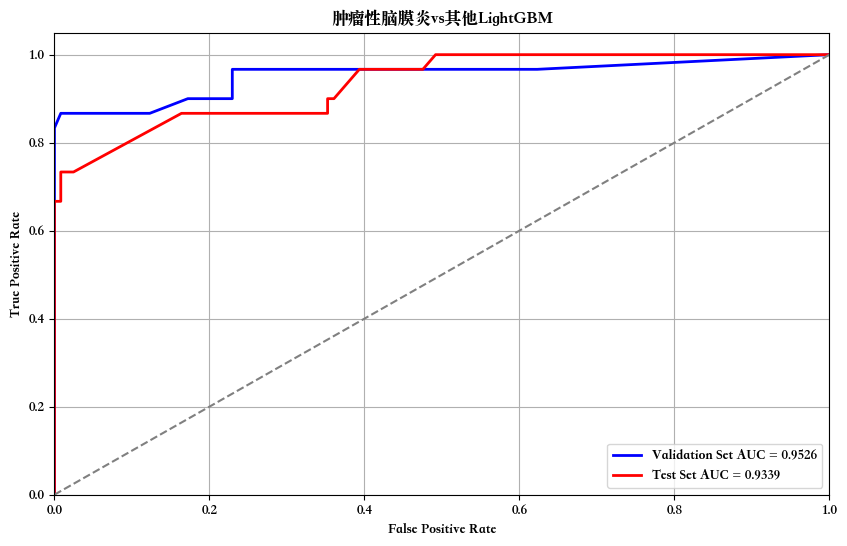

[0.9671, 1.0, 0.8333, 0.9091, 0.9526, 0.9342, 1.0, 0.6667, 0.8, 0.9339]

In [5]:

#注册中文字体到matplotlib
font_path = "/data/home/yansn/anaconda3/envs/naojiye/lib/python3.10/site-packages/matplotlib/mpl-data/fonts/ttf/Songti.ttc"
mpl.font_manager.fontManager.addfont(font_path)
prop = font_manager.FontProperties(fname=font_path)
font_name = prop.get_name()
print("matplotlib 识别的字体名:", font_name)

plt.rcParams['font.family'] = font_name
plt.rcParams['axes.unicode_minus'] = False

# 预测验证集和测试集
y_val_pred = final_model.predict(X_val)
y_test_pred = final_model.predict(X_test)

# 预测验证集和测试集的概率（用于绘制 AUC 曲线）
y_val_prob = final_model.predict_proba(X_val)[:, 1]
y_test_prob = final_model.predict_proba(X_test)[:, 1]

# 计算准确率、精确率、召回率和F1分数
val_accuracy = accuracy_score(y_val, y_val_pred)
test_accuracy = accuracy_score(y_test, y_test_pred)

val_precision = precision_score(y_val, y_val_pred)
test_precision = precision_score(y_test, y_test_pred)

val_recall = recall_score(y_val, y_val_pred)
test_recall = recall_score(y_test, y_test_pred)

val_f1 = f1_score(y_val, y_val_pred)
test_f1 = f1_score(y_test, y_test_pred)

# 输出模型评估结果
print("Validation Set Performance:")
print(f"Accuracy: {val_accuracy:.4f}")
print(f"Precision: {val_precision:.4f}")
print(f"Recall: {val_recall:.4f}")
print(f"F1-Score: {val_f1:.4f}")

print("\nTest Set Performance:")
print(f"Accuracy: {test_accuracy:.4f}")
print(f"Precision: {test_precision:.4f}")
print(f"Recall: {test_recall:.4f}")
print(f"F1-Score: {test_f1:.4f}")

# 绘制 ROC 曲线和 AUC
fpr_val, tpr_val, _ = roc_curve(y_val, y_val_prob)
fpr_test, tpr_test, _ = roc_curve(y_test, y_test_prob)

# 计算 AUC
roc_auc_val = auc(fpr_val, tpr_val)
roc_auc_test = auc(fpr_test, tpr_test)

# 绘制 ROC 曲线
plt.figure(figsize=(10, 6))
plt.plot(fpr_val, tpr_val, color='blue', lw=2, label=f'Validation Set AUC = {roc_auc_val:.4f}')
plt.plot(fpr_test, tpr_test, color='red', lw=2, label=f'Test Set AUC = {roc_auc_test:.4f}')
plt.plot([0, 1], [0, 1], color='gray', linestyle='--')  # 对角线
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('肿瘤性脑膜炎vs其他LightGBM')
plt.legend(loc="lower right")
plt.grid(True)
plt.show()


[round(val_accuracy,4),round(val_precision,4),round(val_recall,4),round(val_f1,4),round(roc_auc_val,4),round(test_accuracy,4),round(test_precision,4),round(test_recall,4),round(test_f1,4),round(roc_auc_test,4)]



===== SHAP 特征重要性 (柱状图):  =====


/data/home/yansn/anaconda3/envs/naojiye/lib/python3.10/site-packages/shap/explainers/_tree.py:583: UserWarning: LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray
  warnings.warn(


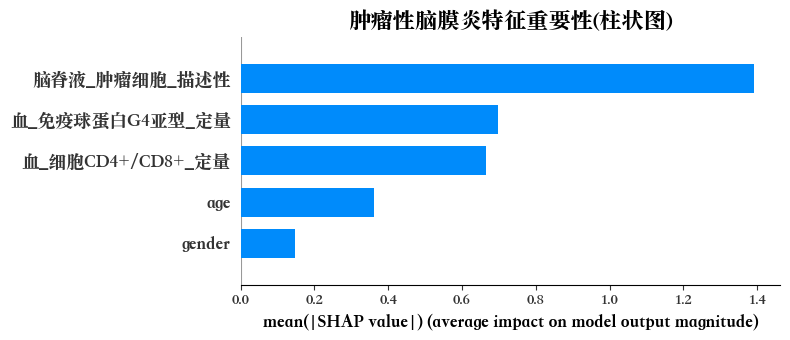


===== SHAP 特征分布 (蜂群图): =====


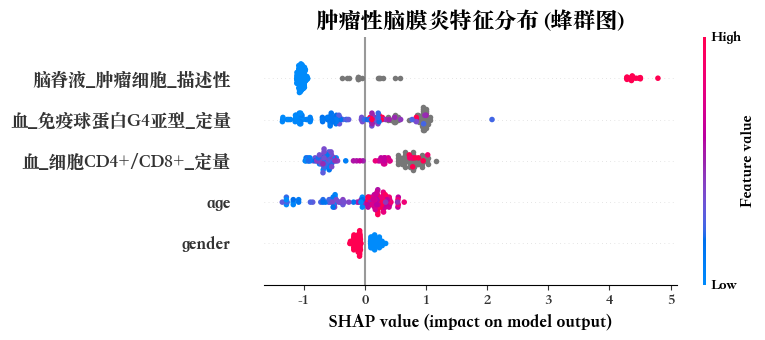

In [76]:

# ---------------- SHAP 分析 -----------------
explainer = shap.TreeExplainer(final_model)
shap_values = explainer.shap_values(X_test)
shap_matrix = shap_values[1] if isinstance(shap_values, list) else shap_values

print(f"\n===== SHAP 特征重要性 (柱状图):  =====")
plt.title("肿瘤性脑膜炎特征重要性(柱状图)", fontsize=16, fontweight='bold')
plt.tight_layout()
shap.summary_plot(shap_matrix, X_test, plot_type="bar", show=True)
plt.title("肿瘤性脑膜炎特征分布 (蜂群图)", fontsize=16, fontweight='bold')
plt.tight_layout()

print(f"\n===== SHAP 特征分布 (蜂群图): =====")
shap.summary_plot(shap_matrix, X_test, show=True)

/data/home/yansn/anaconda3/envs/naojiye/lib/python3.10/site-packages/shap/plots/_waterfall.py:279: UserWarning: Glyph 8722 (\N{MINUS SIGN}) missing from font(s) Songti SC.
  text_bbox = txt_obj.get_window_extent(renderer=renderer)
/data/home/yansn/anaconda3/envs/naojiye/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 8722 (\N{MINUS SIGN}) missing from font(s) Songti SC.
  fig.canvas.print_figure(bytes_io, **kw)


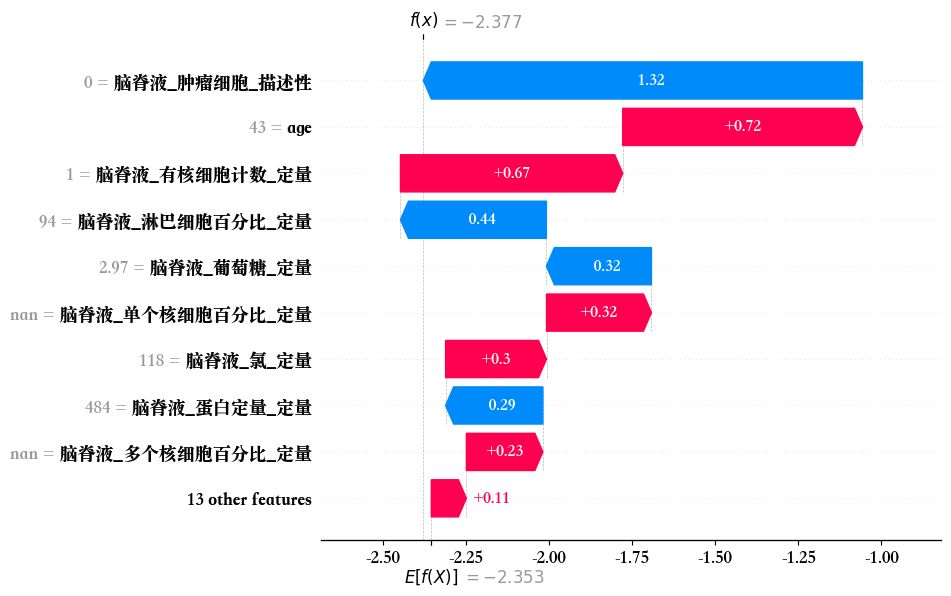

In [7]:
# 生成第一个样本的瀑布图
shap.plots.waterfall(shap.Explanation(values=shap_values[8], 
                                     base_values=explainer.expected_value, 
                                     data=X_test.iloc[8], 
                                     feature_names=X_test.columns))
plt.show()